# Legacy exploratory notebook — superseded
This notebook predates the audited engine and is retained only as development history. Its outputs are not current research results. In particular, early backtest notebooks contain obsolete timing, missing-return filtering, and drawdown calculations. Do not use them to validate performance or overwrite the bundled data. Use the root Python entrypoints and [methodology](../docs/METHODOLOGY.md).

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
prices = pd.read_parquet("../data/raw/us_stock.parquet")
benchmark = pd.read_parquet("../data/raw/benchmark.parquet")

close = prices["Close"].copy()
benchmark_close = benchmark["Close"].copy()

close.head()

Ticker,AAPL,ABBV,AMZN,COST,CVX,GOOGL,HD,JPM,KO,MA,META,MSFT,NVDA,PEP,PG,TSLA,UNH,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,
2015-01-02,24.171757,41.119228,15.4260,113.634468,68.898331,26.244781,78.780350,46.066788,29.390272,79.714668,77.767090,39.681736,0.482423,66.582962,65.070015,14.620667,83.352692,60.974831,23.127544,57.145546
2015-01-05,23.490793,40.345398,15.1095,112.342575,66.144371,25.744715,77.127525,44.636658,29.390272,77.472488,76.518059,39.316849,0.474275,66.082344,64.760620,14.006000,81.979774,59.628880,23.060240,55.581936
2015-01-06,23.493008,40.145714,14.7645,113.827087,66.113747,25.109352,76.891396,43.479259,29.613443,77.305023,75.487091,38.739765,0.459896,65.581779,64.465637,14.085333,81.814339,59.244663,23.237934,55.286457
2015-01-07,23.822432,41.768253,14.9210,115.809135,66.058678,25.035503,79.526817,43.545616,29.983091,78.507530,75.487091,39.231953,0.458697,67.499466,64.803802,14.063333,82.649704,60.038418,23.854490,55.846664
2015-01-08,24.737745,42.205105,15.0230,116.804153,67.570320,25.122732,81.286285,44.518688,30.345758,79.728683,77.499428,40.386101,0.475952,68.726234,65.544846,14.041333,86.594841,60.843693,24.357964,56.776207


In [9]:
returns = close.pct_change(fill_method=None)
benchmark_returns = benchmark_close.pct_change(fill_method=None)

In [10]:
momentum_60 = close.pct_change(60)
month_end_dates = close.resample("ME").last().index

month_end_dates[:10]

monthly_close = close.resample("ME").last()

monthly_close.head()

Ticker,AAPL,ABBV,AMZN,COST,CVX,GOOGL,HD,JPM,KO,MA,META,MSFT,NVDA,PEP,PG,TSLA,UNH,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,
2015-01-31,25.902891,37.944683,17.726500,114.741829,62.747787,26.641266,79.534416,40.088200,28.713741,76.466042,75.249191,34.284496,0.460135,66.117622,61.076527,13.573333,87.876831,58.648773,22.879841,53.815186
2015-02-28,28.513294,38.038998,19.007999,122.127060,65.928970,27.884245,87.402542,45.174797,30.199303,84.016647,78.282555,37.477062,0.530712,69.783760,61.685181,13.556000,93.980621,62.535439,22.597143,54.914925
2015-03-31,27.618786,36.806656,18.605000,125.899872,64.878365,27.491232,86.979515,44.658772,28.515987,80.530312,81.504272,34.750683,0.503527,67.866623,59.373692,12.584667,98.162148,60.306568,22.277834,52.719303
2015-04-30,27.778593,40.991764,21.089001,119.202988,68.635849,27.197336,81.903610,46.944382,28.523037,84.245560,78.084290,41.570908,0.534080,67.511742,58.076336,15.070000,92.444519,60.896667,21.140245,54.189259
2015-05-31,29.038061,42.215298,21.461500,118.819656,64.289040,27.026350,85.302849,48.814438,28.804323,86.160004,78.500641,40.309887,0.534860,68.441505,57.258278,16.719999,99.755432,63.432262,20.243370,53.280422


In [11]:
monthly_momentum = monthly_close.pct_change(3)

monthly_momentum.head()

Ticker,AAPL,ABBV,AMZN,COST,CVX,GOOGL,HD,JPM,KO,MA,META,MSFT,NVDA,PEP,PG,TSLA,UNH,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,
2015-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-04-30,0.072413,0.080303,0.189688,0.038880,0.093837,0.020873,0.029788,0.171027,-0.006642,0.101738,0.037676,0.212528,0.160702,0.021085,-0.049122,0.110265,0.051978,0.038328,-0.076032,0.006951
2015-05-31,0.018404,0.109790,0.129077,-0.027082,-0.024874,-0.030766,-0.024023,0.080568,-0.046192,0.025511,0.002786,0.075588,0.007817,-0.019234,-0.071766,0.233402,0.061447,0.014341,-0.104162,-0.029764


In [12]:
def select_top_n(momentum_row, n=5):
    return (
        momentum_row
        .dropna()
        .sort_values(ascending=False)
        .head(n)
        .index
        .tolist()
    )

In [13]:
test_date = monthly_momentum.dropna().index[0]

top5 = select_top_n(
    monthly_momentum.loc[test_date],
    n=5
)

print(test_date)
print(top5)

2015-04-30 00:00:00
['MSFT', 'AMZN', 'JPM', 'NVDA', 'TSLA']


In [14]:
monthly_returns = monthly_close.pct_change(fill_method=None)

next_month_returns = monthly_returns.shift(-1)

In [15]:
portfolio_results = []

for date in monthly_momentum.index[:-1]:

    momentum_row = monthly_momentum.loc[date]

    selected = select_top_n(
        momentum_row,
        n=5
    )

    if len(selected) == 0:
        continue

    future_returns = next_month_returns.loc[
        date,
        selected
    ].dropna()

    if len(future_returns) == 0:
        continue

    portfolio_return = future_returns.mean()

    portfolio_results.append({
        "date": date,
        "portfolio_return": portfolio_return,
        "holdings": selected
    })

In [16]:
backtest = pd.DataFrame(portfolio_results)

backtest.head()

backtest[["date", "holdings"]].head(10)

backtest["cumulative_return"] = (
    1 + backtest["portfolio_return"]
).cumprod()

backtest.head()

,date,portfolio_return,holdings,cumulative_return
0,2015-04-30,0.027623,"[MSFT, AMZN, JPM, NVDA, TSLA]",1.027623
1,2015-05-31,0.012444,"[TSLA, AMZN, ABBV, JPM, MSFT]",1.040411
2,2015-06-30,0.070536,"[TSLA, AMZN, ABBV, JPM, MSFT]",1.113797
3,2015-07-31,-0.044622,"[AMZN, GOOGL, META, TSLA, V]",1.064098
4,2015-08-31,-0.007512,"[AMZN, GOOGL, META, HD, V]",1.056104


In [17]:
benchmark_monthly = (
    benchmark_close
    .resample("ME")
    .last()
    .pct_change(fill_method=None)
)

benchmark_series = benchmark_monthly.reindex(
    backtest["date"]
)

benchmark_cumulative = (
    1 + benchmark_series
).cumprod()

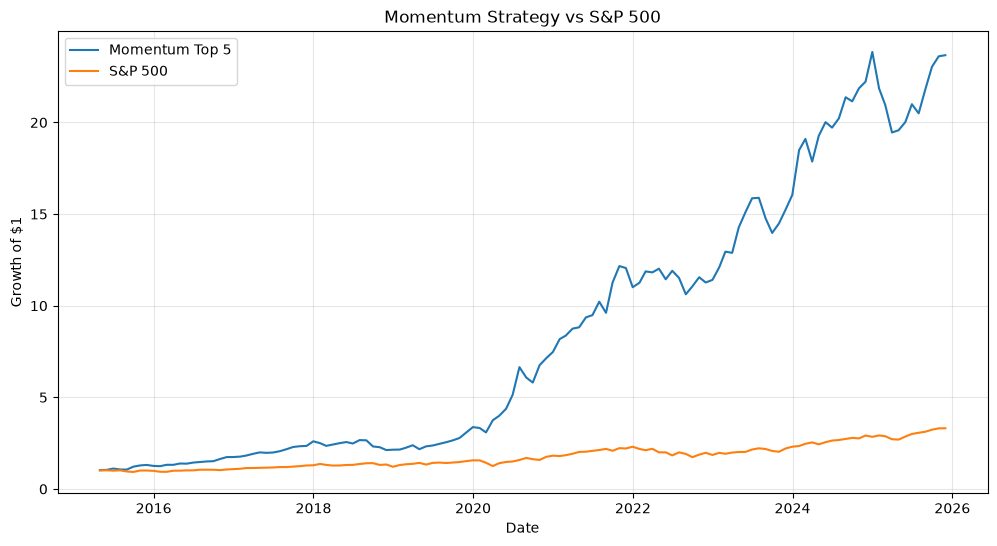

In [18]:
plt.figure(figsize=(12, 6))

plt.plot(
    backtest["date"],
    backtest["cumulative_return"],
    label="Momentum Top 5"
)

plt.plot(
    backtest["date"],
    benchmark_cumulative.values,
    label="S&P 500"
)

plt.title("Momentum Strategy vs S&P 500")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [19]:
strategy_returns = backtest["portfolio_return"].dropna()

annual_return = (
    (1 + strategy_returns).prod()
    ** (12 / len(strategy_returns))
    - 1
)

annual_return

annual_volatility = (
    strategy_returns.std()
    * np.sqrt(12)
)

annual_volatility

sharpe_ratio = (
    strategy_returns.mean()
    / strategy_returns.std()
) * np.sqrt(12)

sharpe_ratio

wealth = (
    1 + strategy_returns
).cumprod()

running_max = wealth.cummax()

drawdown = (
    wealth / running_max
) - 1

max_drawdown = drawdown.min()

max_drawdown

np.float64(-0.20346437456941813)

In [20]:
performance = pd.DataFrame({
    "Metric": [
        "Annual Return",
        "Annual Volatility",
        "Sharpe Ratio",
        "Max Drawdown"
    ],
    "Value": [
        annual_return,
        annual_volatility,
        sharpe_ratio,
        max_drawdown
    ]
})

performance

,Metric,Value
0,Annual Return,0.345331
1,Annual Volatility,0.216053
2,Sharpe Ratio,1.492324
3,Max Drawdown,-0.203464


In [21]:
backtest.to_parquet("../data/processed/backtest.parquet")